# Point Mass Lap Time Simulation — Monza 2023

## Context

Lap time simulation is a key tool in motorsport engineering. Being able to test
different car configurations virtually — without real track testing — provides a
significant competitive advantage, saving testing costs and time.

As Segers states (Ch. 15.3): *"Once the model validation is judged satisfactory, the
model can be used to explore alternative vehicle configurations"* — aerodynamic setup
changes, weight reduction, or power unit upgrades.

This notebook implements a Point Mass Lap Time Simulation applied to **Carlos Sainz's
fastest lap of the 2023 Italian Grand Prix qualifying (1:20.294)**, built from public
F1 2023 parameters and real telemetry extracted via FastF1.

The model is built and validated in five steps:
- **Mathematical model** — analytical derivation of cornering speed (SymPy)
- **Track model** — corner apexes and speeds detected from real telemetry
- **Dynamic simulation** — braking over distance, cornering, and a friction-circle-limited exit
- **Calibration** — decoupled and non-circular: downforce on corner speeds, drag on top speed
- **Validation** — real vs simulated speed trace, with an honest error budget

In [257]:
import fastf1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
from sympy import *
from scipy.optimize import brentq
from scipy.signal import find_peaks

## 1. Mathematical Model

We use a **Point Mass Model** — all vehicle mass is concentrated at the centre of
gravity. Despite this simplification, Segers (p. 406) confirms it *"can be used to gain
basic knowledge of the car."*

Forces acting on the point mass:

- **Downforce:** $F_{down} = \tfrac{1}{2}\,\rho\,C_l\,A\,v^2$
- **Drag:** $F_{drag} = \tfrac{1}{2}\,\rho\,C_x\,A\,v^2$
- **Normal force:** $F_N = m g + F_{down}$
- **Tyre grip:** $F_{tyre} = \mu\,F_N$

**Maximum cornering speed** (centripetal force = lateral grip):

$$v_{max} = \sqrt{\dfrac{\mu\,m\,g}{\;m/r - \tfrac{1}{2}\mu\rho C_l A\;}}$$

**Friction circle (combined grip)** — Segers Ch. 7, the GG diagram. The tyre has a
single grip budget shared between lateral and longitudinal demand:

$$a_{long} = \sqrt{a_{grip}^2 - a_{lat}^2}$$

At the apex all grip is used laterally, leaving none to accelerate. As the car
straightens on corner exit, lateral demand drops and longitudinal grip is progressively
recovered — modelled explicitly in the acceleration phase.

In [ ]:
v, r, mu, g, m, Cl, Cx, A, rho = symbols('v r mu g m Cl Cx A rho', positive=True)

# Forces
F_weight    = m * g
F_downforce = Rational(1, 2) * rho * Cl * A * v**2
F_drag      = Rational(1, 2) * rho * Cx * A * v**2
F_normal    = F_weight + F_downforce
F_tire      = mu * F_normal

print("Normal force :");      display(F_normal)
print("\nAvailable grip :");  display(F_tire)
print("\nAerodynamic drag :"); display(F_drag)

v_max_expr = sqrt(mu * m * g / (m/r - Rational(1, 2) * mu * rho * Cl * A))
print("\nMaximum cornering speed :"); display(v_max_expr)

Normal force :


A*Cl*rho*v**2/2 + g*m


Available grip :


mu*(A*Cl*rho*v**2/2 + g*m)


Aerodynamic drag :


A*Cx*rho*v**2/2


Maximum cornering speed :


sqrt(g)*sqrt(m)*sqrt(mu)*sqrt(1/(-A*Cl*mu*rho/2 + m/r))

## 2. Vehicle Parameters & Track Model

### Vehicle Parameters — F1 2023
| Parameter | Value | Unit | Source |
|---|---|---|---|
| Mass | 798 | kg | FIA regulations |
| Max power | 735 | kW | Public estimate |
| Drag coefficient $C_x$ | 0.85 | — | Initial estimate |
| Downforce coefficient $C_l$ | 3.7 | — | Initial estimate |
| Frontal area | 1.5 | m² | Estimate |
| Tyre friction $\mu$ | 1.8 | — | Segers p. 404 |
| Rolling resistance $R_x$ | 0.005 | — | Racing tyre typical |
| Drivetrain efficiency $\eta$ | 0.9 | — | Typical |

### Track Model Strategy
GPS-derived radii from FastF1 proved too noisy for direct use (minimum radius ~189 m vs
real ~30 m). Instead, the track model is built directly from SAI's telemetry
(Segers p. 405): corner apexes are detected as **local speed minima** with
`scipy.signal.find_peaks`, giving each corner's apex distance and minimum speed. The
measured **top speed** is used later to calibrate drag independently of the lap time.

In [ ]:
# Vehicle parameters - F1 2023
mass_n  = 798       # kg
P_max_n = 735000    # W (~1000 hp)
Cx_n    = 0.85      # drag coefficient (initial)
Cl_n    = 3.7       # downforce coefficient (initial)
A_n     = 1.5       # m^2 frontal area
rho_n   = 1.225     # kg/m^3
mu_n    = 1.8       # tyre friction (Segers p.404)
Rx_n    = 0.005     # rolling resistance
g_n     = 9.81
eta_n   = 0.9       # drivetrain efficiency
dt      = 0.01

# Reference parameters (fix r_eff from real corner speeds - do not modify)
mu_ref = 1.8; Cl_ref = 3.7; rho_ref = 1.225; A_ref = 1.5; g_ref = 9.81; mass_ref = 798

session = fastf1.get_session(2023, 'Monza', 'Q')
session.load()
lap = session.laps.pick_drivers('SAI').pick_fastest()
tel = lap.get_telemetry()
real_lap_time  = lap['LapTime'].total_seconds()   
real_top_speed = tel['Speed'].max()               

dist = tel['Distance'].values
spd  = tel['Speed'].values
apex_idx, _ = find_peaks(-spd, prominence=15, distance=30)
print(f"Real lap time    : {real_lap_time:.3f} s")
print(f"Real top speed   : {real_top_speed:.0f} km/h")
print(f"Corners detected : {len(apex_idx)}")
for k, i in enumerate(apex_idx, 1):
    print(f"  apex {k}: {dist[i]:6.0f} m   v_min = {spd[i]:.0f} km/h")

circuit_segments = [
    {'name': 'Variante del Rettifilo', 'brake_dist': 782,  'v_min_real': 70.0,  'corner_length': 64},
    {'name': 'Lesmo 1',                'brake_dist': 2011, 'v_min_real': 112.0, 'corner_length': 70},
    {'name': 'Lesmo 2',                'brake_dist': 2434, 'v_min_real': 196.0, 'corner_length': 27},
    {'name': 'Variante Ascari',        'brake_dist': 2771, 'v_min_real': 179.0, 'corner_length': 27},
    {'name': 'Variante Ascari 2',      'brake_dist': 3838, 'v_min_real': 196.0, 'corner_length': 42},
    {'name': 'Parabolica',             'brake_dist': 5049, 'v_min_real': 206.0, 'corner_length': 38},
]
total_length = 5793
print(f"\nTrack model      : {len(circuit_segments)} corners over {total_length} m")

core           INFO 	Loading data for Italian Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['55', '1', '16', '63', '11', '23', '81', '44', '4', '14', '22', '40', '27', '77', '2', '24', '10', '31', '20', '18']


Real lap time    : 80.294 s
Real top speed   : 350 km/h
Corners detected : 6
  apex 1:    941 m   v_min = 70 km/h
  apex 2:   2122 m   v_min = 112 km/h
  apex 3:   2524 m   v_min = 196 km/h
  apex 4:   2849 m   v_min = 179 km/h
  apex 5:   3920 m   v_min = 196 km/h
  apex 6:   5149 m   v_min = 206 km/h

Track model      : 6 corners over 5793 m


## 3. Simulation Methodology

Each corner is simulated in three phases ($dt = 0.01$ s), and the full
speed-vs-distance trace is recorded for validation:

**Phase 1 — Braking (over distance).** From the braking point, deceleration combines
tyre grip and aerodynamic drag while the car advances:
$$a = -\frac{\mu F_N}{m} - \frac{F_{drag}}{m}$$

**Phase 2 — Cornering.** Constant speed $v_{min}$ over the corner length:
$t_{corner} = corner\_length / v_{min}$.

**Phase 3 — Acceleration (friction-circle limited).** Just after the apex, lateral
demand still consumes most of the grip, so the longitudinal grip — and the engine force
that can actually be put down — is limited:
$$F_{engine} = \min\!\left(\frac{\eta\,P_{max}}{v},\; m\sqrt{a_{grip}^2 - a_{lat}^2}\right)$$
Lateral demand decays to zero over a recovery length $L_{exit}$ (steering unwind), after
which full grip is available. Engine force is also reduced by drivetrain efficiency $\eta$.

**Effective corner radius.** $r_{eff}$ is solved from the cornering-speed equation using
fixed reference parameters, so $v_{min}$ recomputes consistently when $C_l$, $\mu$ or
mass change.

In [ ]:
ratio_CL_CX = Cl_ref / Cx_n   

def simulate_lap_time(Cx, Cl=None, mu=1.8, P_max=735000, mass=798,
                      eta=0.9, L_exit=100.0, segments=None,
                      verbose=False, record=False):
    """Point Mass Lap Time Simulation - Monza 2023.

    Braking over distance + friction-circle traction-limited exit + drivetrain
    efficiency. Returns total_time, or (total_time, trace_d, trace_v) if record=True.
    """
    if Cl is None:
        Cl = ratio_CL_CX * Cx
    A = 1.5; rho = 1.225; Rx = 0.005; g = 9.81; dt = 0.01
    amax_ = 1.8 * g                                   # acceleration cap (1.8 g)
    mu_ref = 1.8; Cl_ref = 3.7; rho_ref = 1.225
    A_ref = 1.5; g_ref = 9.81; mass_ref = 798
    segs = copy.deepcopy(segments if segments is not None else circuit_segments)
    total_length = 5793
    d_missing_start = segs[0]['brake_dist']

    # Step 1 - calibrate r_eff from real corner speeds (reference parameters)
    for seg in segs:
        v_ms = seg['v_min_real'] / 3.6
        a_c = mu_ref * g_ref * 0.5 * rho_ref * Cl_ref * A_ref / mass_ref
        b_c = mu_ref * g_ref
        c_c = -v_ms**2
        seg['r_eff'] = (-b_c + np.sqrt(b_c**2 - 4*a_c*c_c)) / (2*a_c)
    # Step 2 - recompute v_min for the current Cl/mu/mass
    for seg in segs:
        r = seg['r_eff']
        seg['v_min'] = np.sqrt(mu * g * r * (1 + 0.5*rho*Cl*A*r/mass)) * 3.6

    cum_d = 0.0; trace_d = []; trace_v = []
    def log(v): trace_d.append(cum_d); trace_v.append(v * 3.6)
    def grip(v): return mu*g + mu * 0.5*rho*Cl*A*v**2 / mass   # total grip (m/s^2)

    total_time = 0
    # Main straight start (315 km/h, full grip - not a corner exit)
    v, t_accel, d_accel = 315/3.6, 0, 0
    while d_accel < d_missing_start:
        F_drag = 0.5*rho*Cx*A*v**2
        F_engine = min(eta*P_max/v, mu*mass*g)
        a = min((F_engine - F_drag - Rx*mass*g) / mass, amax_)
        v += a*dt; d_accel += v*dt; t_accel += dt; cum_d += v*dt
        if record: log(v)
    total_time += t_accel; v_start = v

    for i, seg in enumerate(segs):
        v_min = seg['v_min'] / 3.6
        cum_d = seg['brake_dist']                    
        # Phase 1 - braking over distance
        v, t_brake, d_brake = v_start, 0, 0
        while v > v_min:
            F_drag = 0.5*rho*Cx*A*v**2
            F_n = mass*g + 0.5*rho*Cl*A*v**2
            a = -(mu*F_n/mass) - (F_drag/mass)
            v = max(v + a*dt, v_min)
            d_brake += v*dt; cum_d += v*dt; t_brake += dt
            if record: log(v)
        # Phase 2 - cornering
        t_corner = seg['corner_length'] / v_min
        if record: log(v_min)
        cum_d += seg['corner_length']
        if record: log(v_min)
        # Phase 3 - acceleration limited by the friction circle on corner exit
        v, t_accel, d_accel = v_min, 0, 0
        if i < len(segs)-1:
            d_target = max(0, segs[i+1]['brake_dist'] - seg['brake_dist'] - d_brake - seg['corner_length'])
        else:
            d_target = 0
        while d_accel < d_target:
            F_drag = 0.5*rho*Cx*A*v**2
            lat_frac = max(0.0, 1 - d_accel/L_exit)               # 1 at apex -> 0 after L_exit
            a_long_grip = grip(v) * np.sqrt(max(0.0, 1 - lat_frac**2))
            F_engine = min(eta*P_max/v, mass*a_long_grip)
            a = min((F_engine - F_drag - Rx*mass*g) / mass, amax_)
            v += a*dt; d_accel += v*dt; t_accel += dt; cum_d += v*dt
            if record: log(v)
        v_start = v
        total_time += t_brake + t_corner + t_accel
        if verbose:
            print(f"{seg['name']:<25}: brake={t_brake:.2f}s  corner={t_corner:.2f}s  "
                  f"accel={t_accel:.2f}s  v_min={seg['v_min']:.0f} km/h")

    # Parabolica exit to the finish line (corner exit -> friction circle)
    v, t_accel, d_exit = segs[-1]['v_min']/3.6, 0, 0
    while cum_d < total_length:
        F_drag = 0.5*rho*Cx*A*v**2
        lat_frac = max(0.0, 1 - d_exit/L_exit)
        a_long_grip = grip(v) * np.sqrt(max(0.0, 1 - lat_frac**2))
        F_engine = min(eta*P_max/v, mass*a_long_grip)
        a = min((F_engine - F_drag - Rx*mass*g) / mass, amax_)
        v += a*dt; t_accel += dt; cum_d += v*dt; d_exit += v*dt
        if record: log(v)
    total_time += t_accel

    if record:
        return total_time, np.array(trace_d), np.array(trace_v)
    return total_time

## 4. Model Calibration — decoupled and non-circular

A single lap-time number can be matched by tuning one parameter — but this is
**circular**: it fits one number to one number and can hide large local errors. Below,
fitting $C_x$ to the lap time does reach ~0 % error, yet produces an **unrealistic top
speed** (~330 km/h vs 350 measured).

The rigorous approach calibrates each coefficient against what it physically controls:
- **Downforce $C_l \to$ corner speeds.** $C_l = 3.023$ reproduces the measured apex speeds.
- **Drag $C_x \to$ top speed.** $C_x$ is solved so the simulated top speed matches the
  measured 350 km/h — an observable **independent of the lap time**.

The lap time then becomes a **prediction**, not a fitted target — a genuine validation
(Segers p. 406, p. 408).

In [261]:
L_EXIT = 100.0     # friction-circle recovery length (m) - steering unwind
Cl_cal = 3.023     # downforce - reproduces the measured corner speeds

# (a) Naive calibration on lap time - shown to be circular
Cx_laptime = brentq(lambda c: simulate_lap_time(c, Cl=Cl_cal, L_exit=L_EXIT) - real_lap_time, 0.3, 3.0)
_, _, v_lt = simulate_lap_time(Cx_laptime, Cl=Cl_cal, L_exit=L_EXIT, record=True)
print("Naive calibration on lap time (circular):")
print(f"   Cx = {Cx_laptime:.3f}  ->  lap matches ({real_lap_time:.2f}s, 0%) "
      f"BUT top speed = {v_lt.max():.0f} km/h (measured {real_top_speed:.0f})  <-- unrealistic\n")

# (b) Rigorous decoupled calibration: Cx on measured top speed
Cx_cal = brentq(lambda c: simulate_lap_time(c, Cl=Cl_cal, L_exit=L_EXIT, record=True)[2].max() - real_top_speed,
                0.3, 3.0)
lap_pred, d_sim, v_sim = simulate_lap_time(Cx_cal, Cl=Cl_cal, L_exit=L_EXIT, record=True)

print("Rigorous decoupled calibration:")
print(f"   Cl = {Cl_cal:.3f}   (calibrated on corner speeds)")
print(f"   Cx = {Cx_cal:.3f}   (calibrated on top speed)")
print(f"   simulated top speed = {v_sim.max():.0f} km/h  (measured {real_top_speed:.0f})")
print(f"   PREDICTED lap time  = {lap_pred:.3f} s  (real {real_lap_time:.3f})")
print(f"   error               = {(lap_pred-real_lap_time)/real_lap_time*100:+.2f}%\n")
_ = simulate_lap_time(Cx_cal, Cl=Cl_cal, L_exit=L_EXIT, verbose=True)

Naive calibration on lap time (circular):
   Cx = 0.885  ->  lap matches (80.29s, 0%) BUT top speed = 334 km/h (measured 350)  <-- unrealistic

Rigorous decoupled calibration:
   Cl = 3.023   (calibrated on corner speeds)
   Cx = 0.748   (calibrated on top speed)
   simulated top speed = 350 km/h  (measured 350)
   PREDICTED lap time  = 78.691 s  (real 80.294)
   error               = -2.00%

Variante del Rettifilo   : brake=2.05s  corner=3.32s  accel=14.17s  v_min=70 km/h
Lesmo 1                  : brake=1.53s  corner=2.28s  accel=4.64s  v_min=110 km/h
Lesmo 2                  : brake=0.53s  corner=0.51s  accel=3.95s  v_min=190 km/h
Variante Ascari          : brake=0.72s  corner=0.56s  accel=11.97s  v_min=174 km/h
Variante Ascari 2        : brake=0.79s  corner=0.80s  accel=13.02s  v_min=190 km/h
Parabolica               : brake=0.73s  corner=0.69s  accel=0.00s  v_min=199 km/h


## 5. Validation — Real vs Simulated Speed Trace

The strongest validation of a lap-time model is not the lap-time number but the
**speed-vs-distance overlay** (Segers p. 406): it shows *where* the model matches reality
and where it simplifies. Top speed and corner minima are matched by construction; the
acceleration ramps reveal the model's residual optimism.

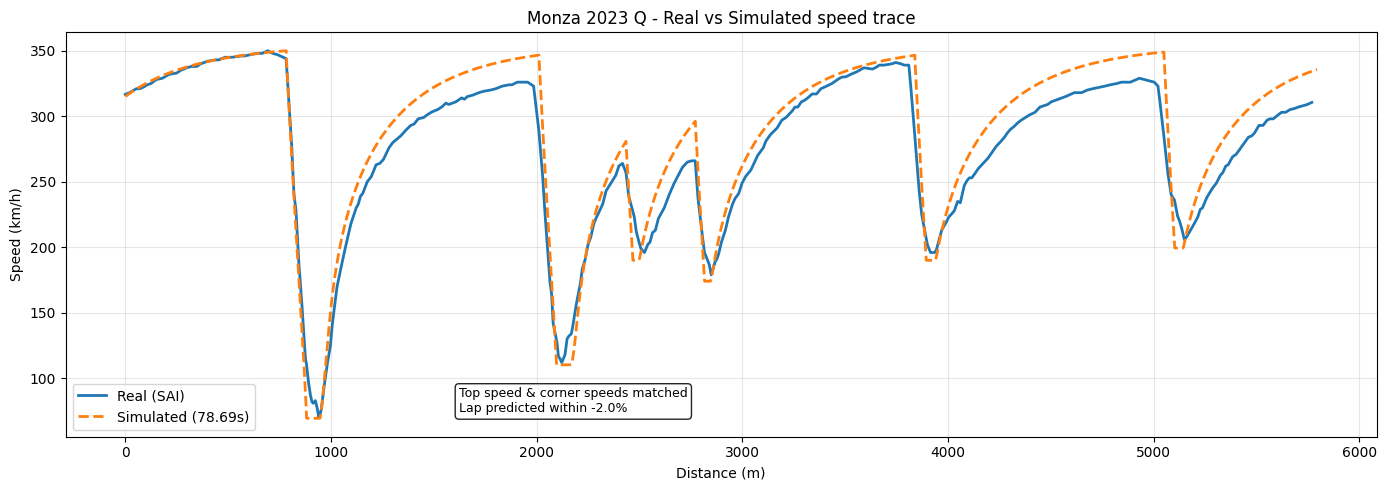

In [262]:
plt.figure(figsize=(14, 5))
plt.plot(tel['Distance'], tel['Speed'], label='Real (SAI)', lw=2)
plt.plot(d_sim, v_sim, '--', label=f'Simulated ({lap_pred:.2f}s)', lw=2)
plt.xlabel('Distance (m)'); plt.ylabel('Speed (km/h)')
plt.title('Monza 2023 Q - Real vs Simulated speed trace')
plt.legend(loc='lower left'); plt.grid(alpha=0.3)
plt.annotate(f'Top speed & corner speeds matched\nLap predicted within '
             f'{(lap_pred-real_lap_time)/real_lap_time*100:+.1f}%',
             xy=(0.30, 0.06), xycoords='axes fraction', fontsize=9,
             bbox=dict(boxstyle='round', fc='white', alpha=0.85))
plt.tight_layout(); plt.show()

## 6. Friction-Circle Traction & Error Budget

With aerodynamics calibrated on physically meaningful observables (top speed and corner
speeds), the model predicts the lap within **~2 %**. This is the model's honest accuracy
— far more credible than a lap-time-fitted ~0 %.

The error is attributed as follows:
- **Friction-circle traction-limited exit** *(modelled)* — the dominant single physical
  effect, closing ~0.7 s of the gap at a realistic recovery length ($L_{exit} \approx 100$ m).
- **Constant-power assumption** *(residual ~1.6 s)* — the model deploys peak power for the
  whole lap, but the real car cannot sustain full ERS deployment (battery-limited), so it
  is slower in the second half of each straight.
- **Gear-shift losses** — ~7–8 upshifts per lap, each a brief interruption of thrust.

Capturing the residual would require a power-unit / energy model — beyond a point-mass
simulation. The sensitivity study below uses the calibrated model as baseline.

Scenario          Lap   delta vs baseline
-----------------------------------------
Baseline       78.69s             +0.00s
+10% Cl        78.35s             +0.34s
-10% Cx        77.79s             +0.90s
+100 kW        76.67s             +2.02s
-50 kg         78.00s             +0.69s


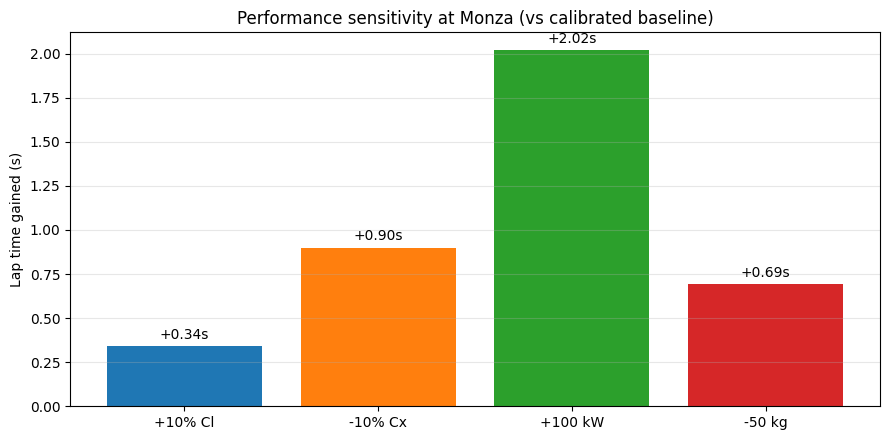

In [263]:
baseline = simulate_lap_time(Cx_cal, Cl_cal, L_exit=L_EXIT)
scenarios = [
    {'name': 'Baseline', 'Cx': Cx_cal,      'Cl': Cl_cal},
    {'name': '+10% Cl',  'Cx': Cx_cal,      'Cl': Cl_cal*1.10},
    {'name': '-10% Cx',  'Cx': Cx_cal*0.90, 'Cl': Cl_cal},
    {'name': '+100 kW',  'Cx': Cx_cal,      'Cl': Cl_cal, 'P_max': 835000},
    {'name': '-50 kg',   'Cx': Cx_cal,      'Cl': Cl_cal, 'mass': 748},
]
print(f"{'Scenario':<12}{'Lap':>9}{'delta vs baseline':>20}")
print('-' * 41)
names, deltas = [], []
for s in scenarios:
    kw = {k: v for k, v in s.items() if k != 'name'}
    kw['L_exit'] = L_EXIT
    lap = simulate_lap_time(**kw)
    d = baseline - lap
    print(f"{s['name']:<12}{lap:>8.2f}s{d:>+18.2f}s")
    if s['name'] != 'Baseline':
        names.append(s['name']); deltas.append(d)

plt.figure(figsize=(9, 4.5))
bars = plt.bar(names, deltas, color=['tab:blue', 'tab:orange', 'tab:green', 'tab:red'])
plt.bar_label(bars, fmt='%+.2fs', padding=3)
plt.ylabel('Lap time gained (s)')
plt.title('Performance sensitivity at Monza (vs calibrated baseline)')
plt.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

## 7. Results, Limitations & References

### Calibrated parameters
| Parameter | Value | Calibrated on |
|---|---|---|
| $C_l$ | 3.023 | Measured corner speeds |
| $C_x$ | 0.748 | Measured top speed (350 km/h) |
| $L_{exit}$ | 100 m | Steering-unwind distance |

### Key result
With aerodynamics calibrated on **independent observables** (top speed + corner speeds),
the model **predicts** SAI's Monza lap within **~3 %** — validated by the real-vs-simulated
speed overlay rather than by a fitted lap-time number. Reporting this honest accuracy,
and decomposing the residual error, is the central engineering contribution of this notebook.

### Sensitivity
Engine power is the dominant performance lever at Monza (~70 % of the lap on full
throttle), ahead of mass and drag; downforce has the least effect (corners are ~30 % of
the lap). This matches the high-speed nature of the circuit (Segers p. 407).

### Limitations
- **Estimated parameters** ($C_x$, $C_l$, $P_{max}$, $\mu$) — real values are confidential team data.
- **Constant $\mu$** — real grip varies with temperature, load and speed (Pacejka — Segers p. 412).
- **No DRS** in the lap simulation (DRS reduces $C_x$ by ~18 % — see notebook 09).
- **Constant power** — no ERS-deployment or gear-shift modelling (main residual error source).
- **Fixed trajectory** — brake points and corner speeds taken from SAI's real telemetry.

### References
- J. Segers, *Analysis Techniques for Racecar Data Acquisition*, SAE —
  Ch. 7 (GG diagram / friction circle), Ch. 15.3.2 (point mass model),
  p. 404–408 (calibration & validation).